# Fall-Detection Dataset · Exploratory Analysis

## Imports

In [30]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
from pathlib import Path
from src.config import PARQUET_DIR
from src.features import _band_power

plt.style.use("ggplot")

## Read Parquet Files

In [10]:
read = lambda p: pd.read_parquet(p)

sub1_dir = PARQUET_DIR / "sub1"
assert sub1_dir.exists(), "Run data_utils --convert first!"

paths = {
    "ADLs":       list((sub1_dir / "ADLs").glob("*.parquet")),
    "Falls":      list((sub1_dir / "Falls").glob("*.parquet")),
    "Near_Falls": list((sub1_dir / "Near_Falls").glob("*.parquet")),
}
for k,v in paths.items():
    print(f"{k}: {len(v)} files")


ADLs: 24 files
Falls: 21 files
Near_Falls: 15 files


In [11]:
adl_df   = pd.concat([read(fp) for fp in paths["ADLs"]], ignore_index=True)
falls_df = pd.concat([read(fp) for fp in paths["Falls"]], ignore_index=True)
near_df  = pd.concat([read(fp) for fp in paths["Near_Falls"]], ignore_index=True)

print("Shapes -> ADL:", adl_df.shape, " Falls:", falls_df.shape, " Near_Falls:", near_df.shape)

Shapes -> ADL: (49305, 64)  Falls: (40343, 64)  Near_Falls: (28815, 64)


In [13]:
adl_df

,time,r.ankle_acceleration_x_m/s^2,r.ankle_acceleration_y_m/s^2,r.ankle_acceleration_z_m/s^2,r.ankle_angular_velocity_x_rad/s,r.ankle_angular_velocity_y_rad/s,r.ankle_angular_velocity_z_rad/s,r.ankle_magnetic_field_x_ut,r.ankle_magnetic_field_y_ut,r.ankle_magnetic_field_z_ut,...,sternum_magnetic_field_z_ut,waist_acceleration_x_m/s^2,waist_acceleration_y_m/s^2,waist_acceleration_z_m/s^2,waist_angular_velocity_x_rad/s,waist_angular_velocity_y_rad/s,waist_angular_velocity_z_rad/s,waist_magnetic_field_x_ut,waist_magnetic_field_y_ut,waist_magnetic_field_z_ut
0,0.00000,-9.197450,-2.342013,-1.119029,0.256876,0.036176,-0.213667,43.971535,16.699480,47.892780,...,-22.639124,-9.331350,-0.676874,0.698558,0.169633,0.961848,-0.203295,31.686543,-61.460712,2.596294
1,0.00781,-9.082349,-2.308569,-1.250646,0.254321,0.047251,-0.185578,43.978161,16.693518,47.383347,...,-25.723372,-9.284102,-0.650755,0.670260,0.178388,0.977692,-0.215142,34.125210,-61.381954,2.551151
2,0.01562,-9.004409,-2.367196,-1.362275,0.261984,0.048375,-0.166692,43.971535,16.699480,47.892780,...,-24.820723,-9.288780,-0.650825,0.665558,0.180301,0.998246,-0.215018,33.980022,-67.447571,-0.339319
3,0.02344,-8.930425,-2.469800,-1.411536,0.267994,0.051086,-0.147838,43.970531,17.188408,47.871067,...,-25.142084,-9.349939,-0.670224,0.663273,0.170527,1.016790,-0.208953,36.563881,-61.303200,2.506008
4,0.03125,-8.821271,-2.506682,-1.387197,0.282256,0.049349,-0.125694,43.970108,17.188393,47.870407,...,-32.217770,-9.378239,-0.684514,0.656242,0.186594,1.029167,-0.190903,36.373585,-67.178581,2.045960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49300,14.96875,-9.687888,-0.258958,-1.602718,0.216034,0.054776,-0.010861,33.582577,19.294926,16.905256,...,-37.594910,-9.730608,-0.340610,1.599483,0.161278,1.120699,-0.022997,40.312656,-27.354780,-21.205492
49301,14.97656,-9.674433,-0.250330,-1.602722,0.217682,0.049907,-0.010804,33.107601,18.802664,16.408155,...,-35.265228,-9.721247,-0.342789,1.575931,0.158085,1.118954,0.030815,45.139954,-30.325191,-23.956224
49302,14.98437,-9.681324,-0.243609,-1.600476,0.219383,0.046608,-0.012324,33.589211,19.288958,16.395256,...,-42.019547,-9.725964,-0.342852,1.604185,0.162063,1.107280,0.000851,40.452908,-24.607328,-23.405890
49303,14.99218,-9.692223,-0.272131,-1.602730,0.217633,0.051619,-0.009252,33.106598,19.292137,16.386419,...,-37.829632,-9.744687,-0.343131,1.594791,0.146610,1.107169,0.024738,40.077259,-33.039921,-19.235117


In [16]:
adl_df.columns

Index(['time', 'r.ankle_acceleration_x_m/s^2', 'r.ankle_acceleration_y_m/s^2',
       'r.ankle_acceleration_z_m/s^2', 'r.ankle_angular_velocity_x_rad/s',
       'r.ankle_angular_velocity_y_rad/s', 'r.ankle_angular_velocity_z_rad/s',
       'r.ankle_magnetic_field_x_ut', 'r.ankle_magnetic_field_y_ut',
       'r.ankle_magnetic_field_z_ut', 'l.ankle_acceleration_x_m/s^2',
       'l.ankle_acceleration_y_m/s^2', 'l.ankle_acceleration_z_m/s^2',
       'l.ankle_angular_velocity_x_rad/s', 'l.ankle_angular_velocity_y_rad/s',
       'l.ankle_angular_velocity_z_rad/s', 'l.ankle_magnetic_field_x_ut',
       'l.ankle_magnetic_field_y_ut', 'l.ankle_magnetic_field_z_ut',
       'r.thigh_acceleration_x_m/s^2', 'r.thigh_acceleration_y_m/s^2',
       'r.thigh_acceleration_z_m/s^2', 'r.thigh_angular_velocity_x_rad/s',
       'r.thigh_angular_velocity_y_rad/s', 'r.thigh_angular_velocity_z_rad/s',
       'r.thigh_magnetic_field_x_ut', 'r.thigh_magnetic_field_y_ut',
       'r.thigh_magnetic_field_z_ut', 'l.

In [14]:
falls_df

,time,r.ankle_acceleration_x_m/s^2,r.ankle_acceleration_y_m/s^2,r.ankle_acceleration_z_m/s^2,r.ankle_angular_velocity_x_rad/s,r.ankle_angular_velocity_y_rad/s,r.ankle_angular_velocity_z_rad/s,r.ankle_magnetic_field_x_ut,r.ankle_magnetic_field_y_ut,r.ankle_magnetic_field_z_ut,...,sternum_magnetic_field_z_ut,waist_acceleration_x_m/s^2,waist_acceleration_y_m/s^2,waist_acceleration_z_m/s^2,waist_angular_velocity_x_rad/s,waist_angular_velocity_y_rad/s,waist_angular_velocity_z_rad/s,waist_magnetic_field_x_ut,waist_magnetic_field_y_ut,waist_magnetic_field_z_ut
0,0.00000,-9.742837,-0.065512,-1.316874,0.216775,0.052098,-0.007826,47.789047,22.591841,2.631973,...,-40.484699,-9.724694,1.343551,0.928446,0.131047,1.103684,0.000757,38.524014,-40.149014,-24.687202
1,0.00782,-9.745291,-0.052242,-1.319083,0.206708,0.058553,-0.003296,48.266102,22.105080,3.172631,...,-40.571339,-9.729620,1.327297,0.930801,0.135304,1.104603,0.024695,40.767452,-49.263798,-30.283260
2,0.01563,-9.752246,-0.041108,-1.316832,0.210113,0.055236,-0.006363,47.789047,22.591841,2.631973,...,-40.249977,-9.736514,1.336443,0.935520,0.144311,1.113817,0.000847,38.378826,-46.214630,-27.577671
3,0.02344,-9.742992,-0.054485,-1.321318,0.215117,0.048763,-0.007819,48.272736,22.099110,2.662552,...,-40.657982,-9.727350,1.322708,0.933151,0.134477,1.114875,0.000830,38.333721,-46.024391,-25.147249
4,0.03125,-9.745142,-0.061092,-1.336929,0.211972,0.056645,-0.012616,47.789047,22.591841,2.631973,...,-43.395664,-9.734364,1.322602,0.923744,0.135429,1.114049,0.024750,38.428867,-43.086700,-24.917227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40338,14.96875,6.057809,-1.969502,7.350640,0.215197,0.044032,0.001417,-21.591106,28.712120,-45.188534,...,-65.396660,-3.321797,-8.144905,-4.246019,0.161309,1.089759,-0.029155,24.110149,6.985611,-25.939068
40339,14.97657,6.046626,-1.978172,7.343954,0.209051,0.054662,-0.012833,-21.597742,28.718090,-44.678329,...,-63.536427,-3.312672,-8.160951,-4.243680,0.152658,1.081789,-0.017261,26.313419,1.379227,-24.013836
40340,14.98438,6.028536,-1.977931,7.326140,0.207140,0.051683,-0.005002,-21.592112,29.201788,-45.210278,...,-70.958672,-3.284713,-8.169782,-4.239008,0.155040,1.090825,0.018680,29.032593,6.952888,-28.459776
40341,14.99219,6.029058,-2.013245,7.319406,0.208895,0.051594,-0.008113,-21.114944,28.714909,-44.669487,...,-65.136742,-3.256663,-8.173994,-4.253167,0.167061,1.092505,0.000777,29.082634,10.080815,-25.799330


In [15]:
near_df

,time,r.ankle_acceleration_x_m/s^2,r.ankle_acceleration_y_m/s^2,r.ankle_acceleration_z_m/s^2,r.ankle_angular_velocity_x_rad/s,r.ankle_angular_velocity_y_rad/s,r.ankle_angular_velocity_z_rad/s,r.ankle_magnetic_field_x_ut,r.ankle_magnetic_field_y_ut,r.ankle_magnetic_field_z_ut,...,sternum_magnetic_field_z_ut,waist_acceleration_x_m/s^2,waist_acceleration_y_m/s^2,waist_acceleration_z_m/s^2,waist_angular_velocity_x_rad/s,waist_angular_velocity_y_rad/s,waist_angular_velocity_z_rad/s,waist_magnetic_field_x_ut,waist_magnetic_field_y_ut,waist_magnetic_field_z_ut
0,0.00000,-9.732105,-0.141962,-1.271959,0.215021,0.060295,-0.014483,47.766918,22.655981,5.308895,...,-45.975834,-9.553204,1.025920,1.865549,0.154447,1.106436,-0.005151,33.816120,-47.926369,-26.756397
1,0.00781,-9.734324,-0.144150,-1.283106,0.214863,0.055586,-0.009750,47.766918,22.655981,5.308895,...,-38.578789,-9.559916,1.046624,1.860855,0.145857,1.103189,0.006770,38.788605,-44.831165,-26.616659
2,0.01562,-9.743513,-0.135186,-1.278625,0.214809,0.052376,-0.008160,47.766918,22.655981,5.308895,...,-33.659500,-9.548281,1.042174,1.865547,0.137581,1.110797,0.012774,38.743500,-44.640926,-24.186237
3,0.02343,-9.738991,-0.135246,-1.274172,0.214875,0.065431,-0.009827,47.766918,22.655981,5.308895,...,-43.003426,-9.555235,1.046694,1.863203,0.142173,1.111386,0.024748,43.761089,-41.735958,-26.476921
4,0.03125,-9.754875,-0.132802,-1.269692,0.216570,0.057209,-0.011309,47.766918,22.655981,5.308895,...,-38.578789,-9.578837,1.034789,1.872644,0.135185,1.105075,0.036655,36.299892,-48.037849,-29.231962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28810,14.96875,-9.010537,-3.885844,0.661367,0.323142,0.084002,-0.008327,56.484806,-1.573000,6.455144,...,-17.148235,-8.366581,-0.556405,-5.388067,0.273679,1.014911,0.078327,38.721943,-28.924248,-20.186440
28811,14.97656,-9.010634,-3.883723,0.656859,0.325031,0.086050,-0.008285,56.476757,-2.055734,6.986577,...,-19.737839,-8.425161,-0.557264,-5.357395,0.267381,1.022273,0.072374,36.473572,-23.127626,-19.681250
28812,14.98437,-8.999099,-3.897153,0.636765,0.323517,0.075938,-0.012922,56.959385,-2.058915,6.995415,...,-17.556238,-8.446162,-0.550633,-5.333828,0.264306,1.012325,0.060347,38.581692,-31.671700,-17.986040
28813,14.99218,-8.994421,-3.908239,0.645662,0.321809,0.072674,-0.011350,56.482388,-1.572216,6.454825,...,-19.824478,-8.474103,-0.539486,-5.324375,0.259400,1.013641,0.060343,36.328381,-29.193243,-22.571718


In [34]:
cols_stern = [c for c in adl_df.columns
              if c.startswith("sternum_acceleration_") and c.endswith("_m/s^2")]

In [35]:
cols_stern

['sternum_acceleration_x_m/s^2',
 'sternum_acceleration_y_m/s^2',
 'sternum_acceleration_z_m/s^2']

## Quick sanity‑check plot

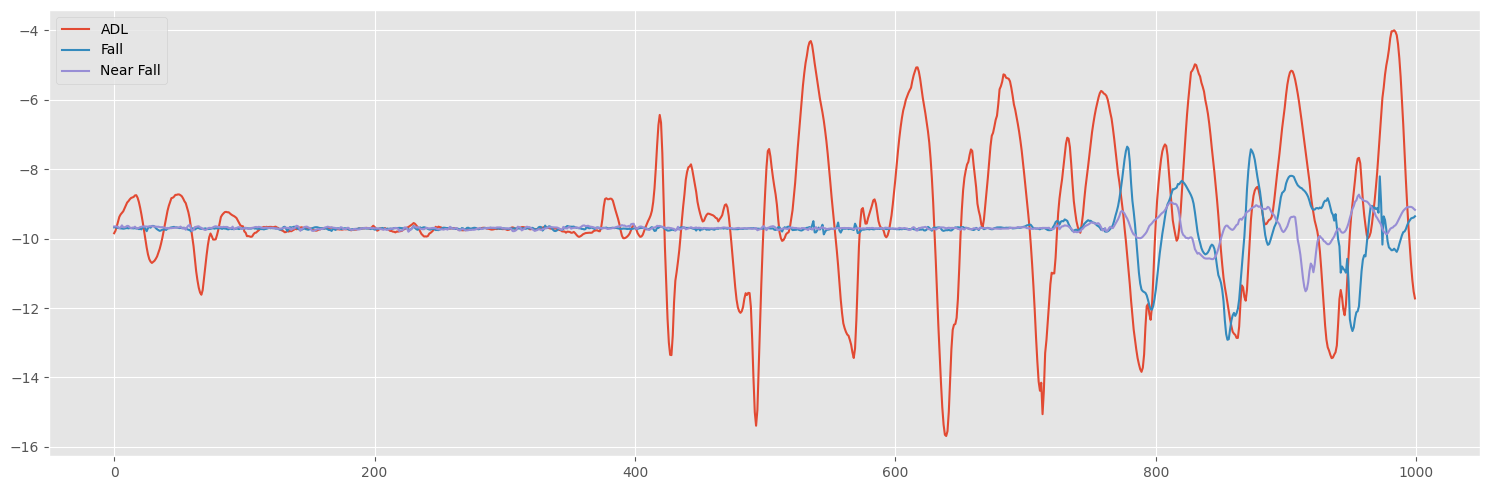

In [22]:
import matplotlib.pyplot as plt

# quick sanity-check plot (use suffix _m/s^2)
peak_cols = [
    "sternum_acceleration_x_m/s^2",
    "sternum_acceleration_y_m/s^2",
    "sternum_acceleration_z_m/s^2",
]

plt.figure(figsize=(15, 5))
plt.plot(adl_df[peak_cols[0]].iloc[:1000], label="ADL")
plt.plot(falls_df[peak_cols[0]].iloc[:1000], label="Fall")
plt.plot(near_df[peak_cols[0]].iloc[:1000], label="Near Fall")
plt.legend(); plt.tight_layout()

## Descriptive statistics per activity

In [36]:
mag = lambda df: (df[cols_stern]**2).sum(1).pow(0.5)
stats = pd.DataFrame({
    "Activity": ["ADL","Fall","Near"],
    "Mean_|a|": [mag(df).mean() for df in (adl_df,falls_df,near_df)],
    "STD_|a|":  [mag(df).std()  for df in (adl_df,falls_df,near_df)],
})
print(stats)

  Activity  Mean_|a|   STD_|a|
0      ADL  9.781131  1.638741
1     Fall  9.988773  3.211404
2     Near  9.867448  1.592297


## Waist |a| band-power (2–5 Hz)

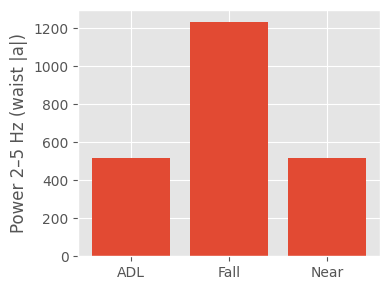

In [37]:
cols_waist = [c for c in adl_df.columns
              if c.startswith("waist_acceleration_") and c.endswith("_m/s^2")]
assert cols_waist, "waist_acceleration columns not found!"

def waist_band_power(df, low=2, high=5, fs=100):
    mag = (df[cols_waist]**2).sum(axis=1).pow(0.5).values
    return _band_power(mag, fs, low, high)

vals = [waist_band_power(df) for df in (adl_df, falls_df, near_df)]

plt.figure(figsize=(4,3))
plt.bar(["ADL","Fall","Near"], vals)
plt.ylabel("Power 2–5 Hz (waist |a|)")
plt.tight_layout()


## Time-to-peak sternum |a|  (per 2 s window)

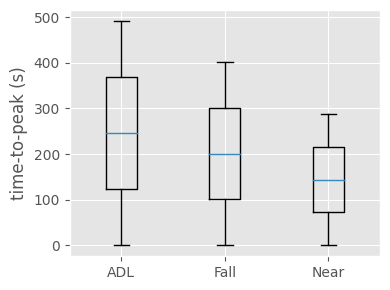

In [38]:
fs = 100
def t_peak(window):
    return window[cols_stern].pow(2).sum(1).pow(0.5).idxmax() / fs

box_data = [
    [t_peak(df.iloc[i:i+200]) for i in range(0, len(df)-199, 200)]
    for df in (adl_df, falls_df, near_df)
]

plt.figure(figsize=(4,3))
plt.boxplot(box_data, labels=["ADL","Fall","Near"])
plt.ylabel("time-to-peak (s)")
plt.tight_layout()

## Distribution – histogram & KDE of sternum |a|

c:\Users\Bruno\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Bruno\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


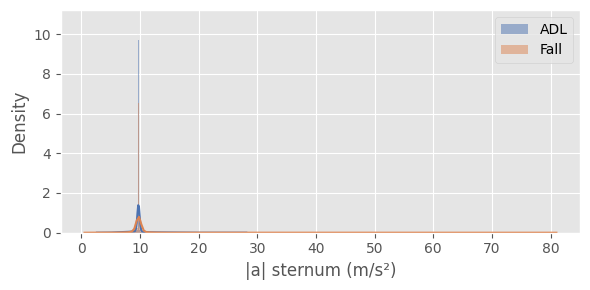

In [39]:
plt.figure(figsize=(6,3))
sns.histplot(mag(adl_df),  color="#4c72b0", label="ADL",  kde=True, stat="density")
sns.histplot(mag(falls_df), color="#dd8452", label="Fall", kde=True, stat="density")
plt.legend(); plt.xlabel("|a| sternum (m/s²)"); plt.tight_layout()

## Full correlation matrix (63 × 63) with clustermap

Text(0.5, 1.0, 'ADL – correlation of all channels')

<Figure size 800x600 with 0 Axes>

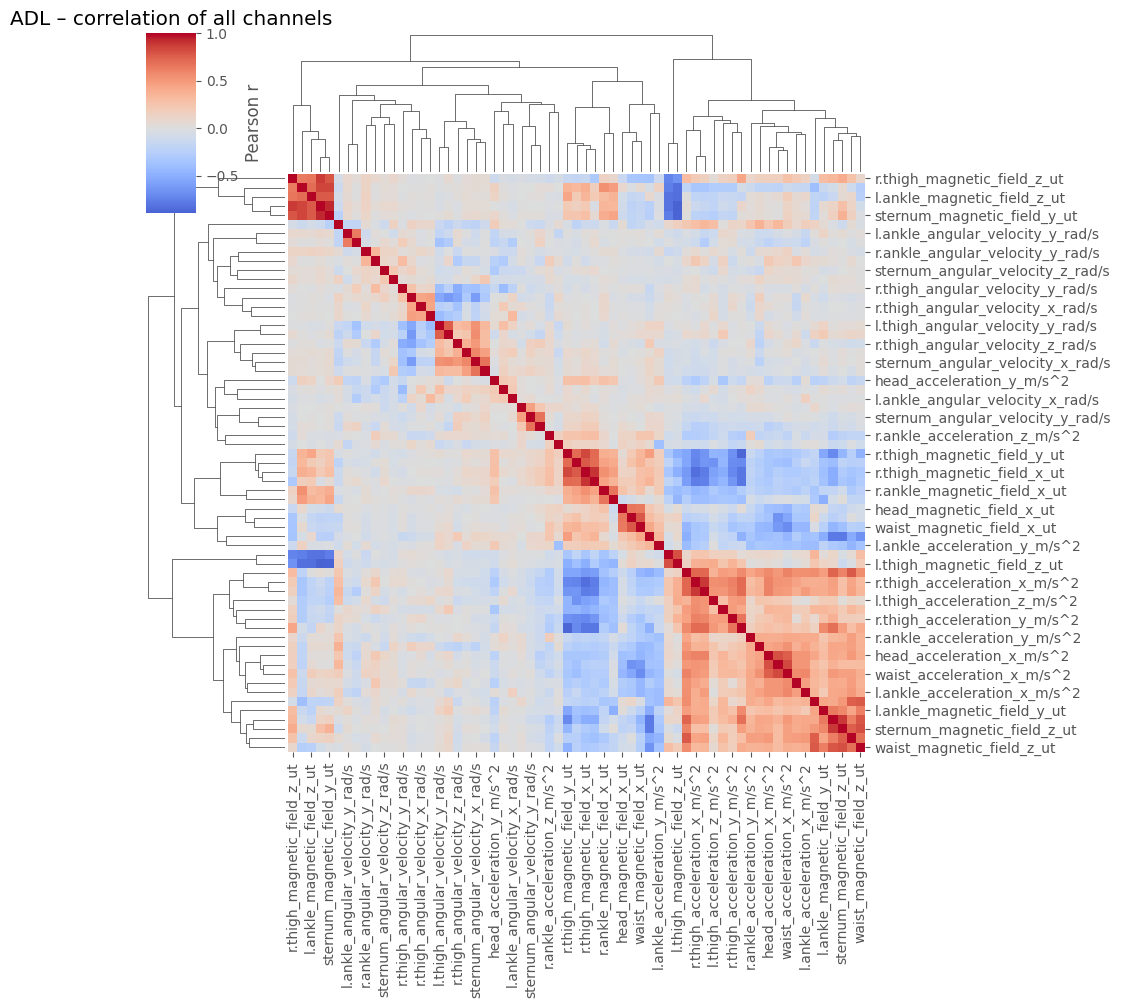

In [40]:
plt.figure(figsize=(8,6))
sns.clustermap(
    adl_df.drop(columns="time").corr(),
    cmap="coolwarm",
    center=0,
    figsize=(10,10),
    cbar_kws=dict(label="Pearson r"),
)
plt.title("ADL – correlation of all channels")

## Autocorrelation of waist |a| (first 10 s)

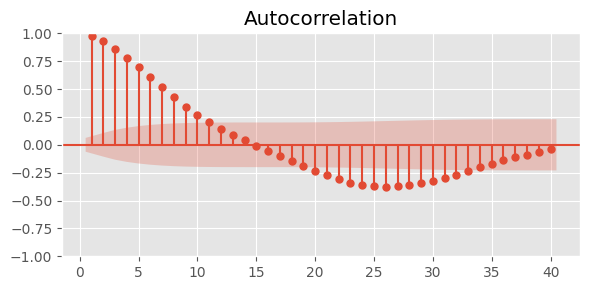

In [41]:
from statsmodels.graphics.tsaplots import plot_acf
waist_mag = (falls_df[[c for c in falls_df.columns
                       if c.startswith("waist_acceleration_") and c.endswith("_m/s^2")]]
             .pow(2).sum(1).pow(0.5).iloc[:1000])
plt.figure(figsize=(6,3))
plot_acf(waist_mag, lags=40, zero=False, ax=plt.gca())
plt.tight_layout()

## PCA (2 components) – raw columns

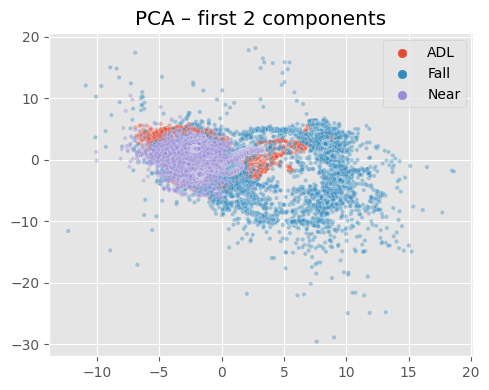

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = pd.concat([adl_df, falls_df, near_df])
y = (["ADL"] * len(adl_df)
     + ["Fall"] * len(falls_df)
     + ["Near"] * len(near_df))

X_std = StandardScaler().fit_transform(X.drop(columns="time"))
pc = PCA(n_components=2).fit_transform(X_std)

plt.figure(figsize=(5,4))
sns.scatterplot(x=pc[:,0], y=pc[:,1], hue=y, alpha=0.4, s=10)
plt.title("PCA – first 2 components")
plt.tight_layout()

## Correlation matrix – Falls vs. ADL (difference)

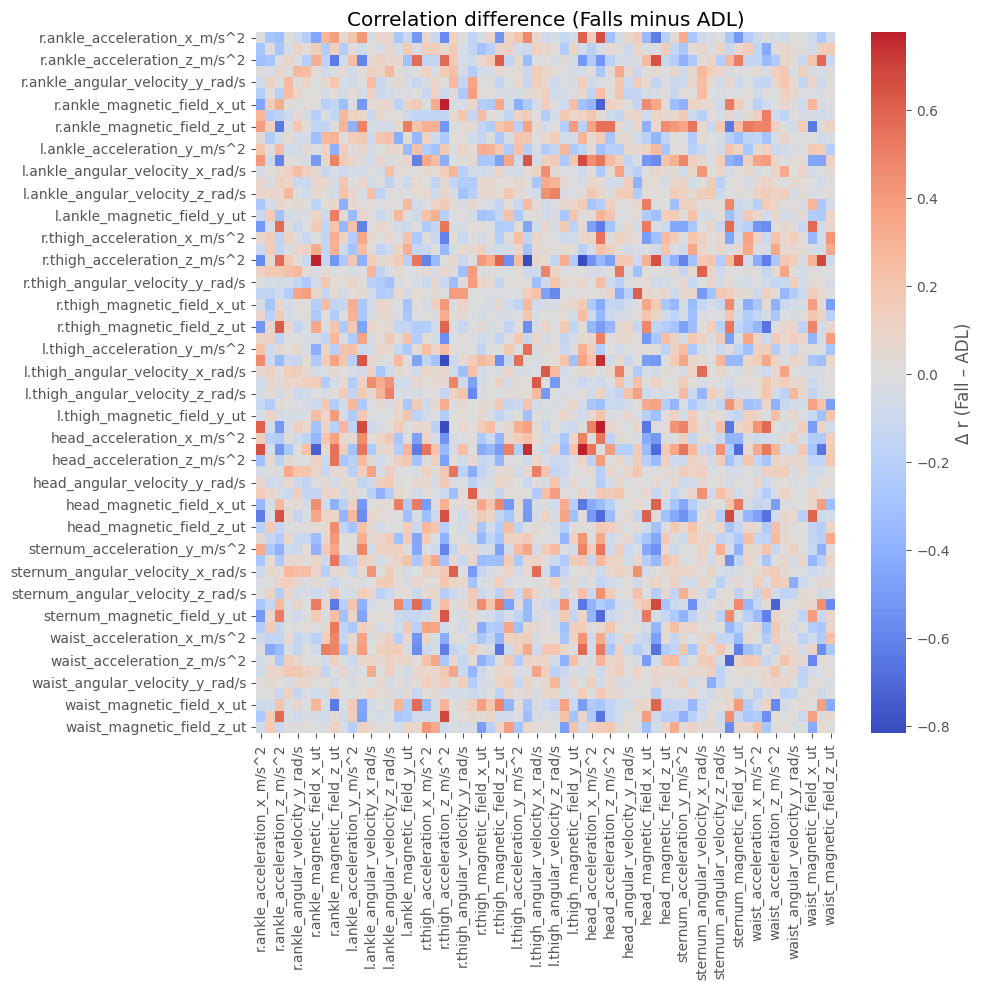

In [44]:
import seaborn as sns, matplotlib.pyplot as plt, numpy as np
corr_adl  = adl_df.drop(columns="time").corr()
corr_fall = falls_df.drop(columns="time").corr()
cor_diff  = corr_fall - corr_adl
plt.figure(figsize=(10,10))
sns.heatmap(cor_diff, cmap="coolwarm", center=0,
            cbar_kws=dict(label="Δ r (Fall – ADL)"))
plt.title("Correlation difference (Falls minus ADL)")
plt.tight_layout()

## Cross‑correlation head ↔ waist |a|

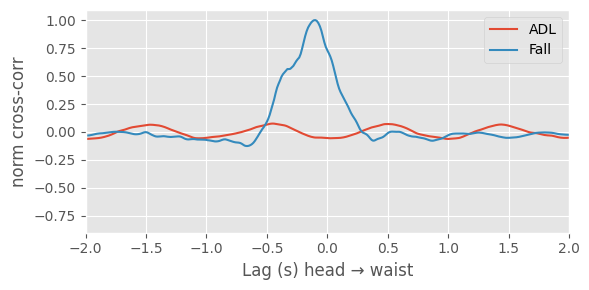

In [48]:
head_cols  = [c for c in adl_df.columns if c.startswith("head_acceleration_")  and c.endswith("_m/s^2")]
waist_cols = [c for c in adl_df.columns if c.startswith("waist_acceleration_") and c.endswith("_m/s^2")]

fs = 100  # Hz

def xcorr_norm(a, b):
    c = np.correlate(a - a.mean(), b - b.mean(), mode="full")
    return c / c.max()

def mag(df, cols):
    return (df[cols]**2).sum(1).pow(0.5).values

a_adl  = mag(adl_df,  head_cols)
b_adl  = mag(adl_df,  waist_cols)
a_fall = mag(falls_df, head_cols)
b_fall = mag(falls_df, waist_cols)

ccf_adl  = xcorr_norm(a_adl,  b_adl)
ccf_fall = xcorr_norm(a_fall, b_fall)

# ensure equal length by trimming to min
L = min(len(ccf_adl), len(ccf_fall))
ccf_adl  = ccf_adl[:L]
ccf_fall = ccf_fall[:L]

lags = np.linspace(-len(a_adl)/fs, len(a_adl)/fs, L)
plt.figure(figsize=(6,3))
plt.plot(lags, ccf_adl,  label="ADL")
plt.plot(lags, ccf_fall, label="Fall")
plt.xlim(-2,2)
plt.xlabel("Lag (s) head → waist")
plt.ylabel("norm cross‑corr")
plt.legend(); plt.tight_layout()

## Random‑Forest feature importance snapshot

c:\Users\Bruno\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\interpolate\_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\Bruno\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\interpolate\_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


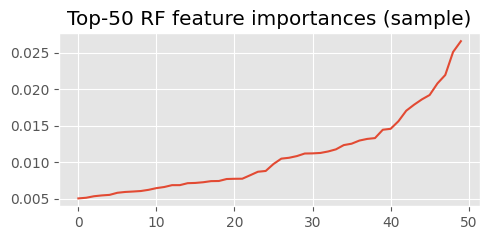

In [50]:
from src.data_utils import create_windows
from src.features import extract_feature_matrix
from src.models.rf import RandomForestFallDetector

# build 500 random windows across activities
pairs = []
for df, lbl in [(adl_df, 0), (falls_df, 2), (near_df, 1)]:
    for w, _ in create_windows(df, lbl):
        pairs.append((w, lbl))

np.random.shuffle(pairs)
pairs_small = pairs[:500]
X_small, y_small = extract_feature_matrix(pairs_small)
rf = RandomForestFallDetector().fit(X_small, y_small)
imp = np.sort(rf.clf.feature_importances_)[-50:]
plt.figure(figsize=(5,2.5))
plt.plot(imp)
plt.title("Top‑50 RF feature importances (sample)")
plt.tight_layout()

## Sensor pairs with strongest Δ-correlation (|Δr| > 0.5)

In [51]:
rows, cols = np.where(np.abs(cor_diff.values) > 0.5)
pairs = [ (cor_diff.index[r], cor_diff.columns[c], cor_diff.values[r,c])
          for r,c in zip(rows, cols) if r < c ]  # avoid duplicates
pairs_sorted = sorted(pairs, key=lambda x: -abs(x[2]))[:10]
print("Top 10 channel pairs with largest |Δr| (Fall-ADL):")
for a,b,val in pairs_sorted:
    print(f"{a:35s} ↔ {b:35s}  Δr={val:+.2f}")

Top 10 channel pairs with largest |Δr| (Fall-ADL):
r.thigh_acceleration_z_m/s^2        ↔ l.thigh_magnetic_field_z_ut          Δr=-0.82
r.thigh_acceleration_z_m/s^2        ↔ l.thigh_acceleration_z_m/s^2         Δr=-0.81
r.ankle_magnetic_field_x_ut         ↔ r.thigh_acceleration_z_m/s^2         Δr=+0.78
l.thigh_magnetic_field_z_ut         ↔ head_acceleration_y_m/s^2            Δr=+0.77
l.thigh_acceleration_z_m/s^2        ↔ head_acceleration_y_m/s^2            Δr=+0.75
r.ankle_magnetic_field_x_ut         ↔ head_acceleration_y_m/s^2            Δr=-0.73
sternum_magnetic_field_x_ut         ↔ waist_acceleration_z_m/s^2           Δr=-0.73
head_acceleration_y_m/s^2           ↔ sternum_magnetic_field_y_ut          Δr=-0.69
head_acceleration_y_m/s^2           ↔ head_magnetic_field_y_ut             Δr=-0.69
r.thigh_acceleration_z_m/s^2        ↔ waist_magnetic_field_y_ut            Δr=+0.69


## Average Δ-correlation across all subjects

In [55]:
from src.data_utils import list_trials 

In [57]:
all_diffs = []
for subj in sorted({p[0] for p in list_trials(Path("data"))}):
    adl_files  = list((PARQUET_DIR/subj/"ADLs").glob("*.parquet"))
    fall_files = list((PARQUET_DIR/subj/"Falls").glob("*.parquet"))
    if adl_files and fall_files:
        adl  = pd.read_parquet(adl_files[0]).drop(columns="time").corr()
        fall = pd.read_parquet(fall_files[0]).drop(columns="time").corr()
        all_diffs.append(fall - adl)

if all_diffs:  # avoid ZeroDivisionError
    mean_diff = sum(all_diffs) / len(all_diffs)
    plt.figure(figsize=(6,5))
    sns.heatmap(mean_diff, cmap="coolwarm", center=0, cbar=False)
    plt.title("Mean Δr across subjects (Falls-ADL)")
    plt.tight_layout()
else:
    print("No subjects with both ADL and Fall files detected – skipping plot.")

No subjects with both ADL and Fall files detected – skipping plot.


## Prototype: Δ-corr features for XGBoost

In [62]:
from src.data_utils import create_windows
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

sel_pairs = [(a, b) for a, b, _ in pairs_sorted]
colnames  = adl_df.drop(columns="time").columns  # 63 names

import pandas as pd, numpy as np

def delta_feat(win_arr):
    df = pd.DataFrame(win_arr, columns=colnames)
    C  = df.corr()
    return np.array([C.loc[a, b] for a, b in sel_pairs])

# assemble dataset
X, y = [], []
for df, lab in ((adl_df,0), (falls_df,2), (near_df,1)):
    for w,_ in create_windows(df, lab):
        X.append(delta_feat(w))
        y.append(lab)
X = np.vstack(X); y = np.array(y)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3,
                                          stratify=y, random_state=42)

xgb = XGBClassifier(n_estimators=120, max_depth=3, learning_rate=0.1,
                    objective="multi:softprob", num_class=3,
                    random_state=42, n_jobs=-1)
xgb.fit(X_tr, y_tr)

y_pred = xgb.predict(X_te)
print("Δ‑corr XGB  – test accuracy:", accuracy_score(y_te, y_pred))
print("Δ‑corr XGB  – test macro‑F1:", f1_score(y_te, y_pred, average="macro"))


c:\Users\Bruno\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\interpolate\_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\Bruno\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\interpolate\_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


Δ‑corr XGB  – test accuracy: 1.0
Δ‑corr XGB  – test macro‑F1: 1.0
